# Modelo Predictivo de Incidencia Delictiva Estatal

Ahora, lo que buscamos es construir un modelo de regresión capaz de predecir la incidencia delictiva mensual a nivel estatal en México, utilizando como variables predictoras la entidad federativa, el bien jurídico afectado, el tipo y subtipo de delito, la modalidad y _features_ temporales (año, mes, trimestre).

Para esto utilizaremos un **Random Forest Regressor** dentro de un pipeline de scikit-learn que incluye lo siguiente:

- **Preprocesamiento**: codificación One-Hot de variables categóricas y estandarización de variables numéricas.
- **Búsqueda de hiperparámetros**: Usaremos `RandomizedSearchCV` con validación cruzada de 3 pliegues, más eficiente que una búsqueda exhaustiva para este volumen de datos.
- **Transformación del objetivo**: Aplicaremos `log1p` a la variable objetivo para mitigar el sesgo observado en el EDA.

El dataset contiene ~414,000 registros de incidencia delictiva estatal , por lo que trabajar con todos estos registros es demasiado pesado en recursos. Es por esto que para este modelo trabajaremos con una muestra estratificada de 50,000 registros que preserva la proporción de tipos de delito.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from src.model.preprocesamiento import (
    cargar_preparar_datos,
    separar_features_target,
    construir_preprocesador,
)
from src.model.entrenamiento import entrenar_random_forest
from src.model.evaluacion import (
    evaluar_modelo,
    grafica_predicciones,
    grafica_residuales,
)
from src.model.persistencia import guardar_modelo, cargar_modelo

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

# Carga y preparación de datos

Cargamos el dataset limpio resultado del EDA y aplicamos un muestreo estratificado sobre la columna `tipo_delito` para reducir los ~414,000 registros a 50,000. Esto preserva la distribución de tipos de delito y reduce drásticamente el tiempo de entrenamiento sin comprometer la calidad del modelo, ya que Random Forest muestra rendimientos decrecientes con volúmenes de datos muy grandes.

Luego, separamos las features de nuestra variable objetivo: `incidencia_delictiva`, y aplicamos una transformación logarítmica con `log1p` para compensar el fuerte sesgo a la derecha observado en el EDA.

In [16]:
RUTA_DATOS = str(
    Path.cwd().parent / "data" / "processed" / "INM_estatal_dic25_clean.csv"
)  # por alguna razón así identificó más fácil la ruta

df = cargar_preparar_datos(RUTA_DATOS)
print(f"Muestra estratificada: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.head(3)

Muestra estratificada: 50,000 filas x 7 columnas


,fecha,entidad,bien_juridico_afectado,tipo_delito,subtipo_delito,modalidad,incidencia_delictiva
249379,2021-03-01,Puebla,El patrimonio,Otros delitos contra el patrimonio,Otros delitos contra el patrimonio,Otros delitos contra el patrimonio,26
57395,2016-09-01,Morelos,La vida y la Integridad corporal,Lesiones,Lesiones dolosas,No especificado,144
289658,2022-12-01,Quintana Roo,El patrimonio,Robo,Robo de vehículo automotor,Robo de coche de 4 ruedas Con violencia,11


La columna `fecha`, al ser de tipo datetime, se descompone en tres features numéricas: `anio`, `mes` y `trimestre`. Esto permite al modelo capturar tendencias temporales (tendencia anual, estacionalidad mensual y patrones por trimestre) sin introducir alta cardinalidad como haría un One-Hot de fechas individuales.

In [17]:
X, y = separar_features_target(df)

print(f"Features: {X.shape[1]} columnas")
print(f"Columnas: {list(X.columns)}")
print(f"\nTarget (log1p) — media: {y.mean():.3f}, std: {y.std():.3f}")
X.head(3)

Features: 8 columnas
Columnas: ['entidad', 'bien_juridico_afectado', 'tipo_delito', 'subtipo_delito', 'modalidad', 'anio', 'mes', 'trimestre']

Target (log1p) — media: 1.753, std: 1.990


,entidad,bien_juridico_afectado,tipo_delito,subtipo_delito,modalidad,anio,mes,trimestre
249379,Puebla,El patrimonio,Otros delitos contra el patrimonio,Otros delitos contra el patrimonio,Otros delitos contra el patrimonio,2021,3,1
57395,Morelos,La vida y la Integridad corporal,Lesiones,Lesiones dolosas,No especificado,2016,9,3
289658,Quintana Roo,El patrimonio,Robo,Robo de vehículo automotor,Robo de coche de 4 ruedas Con violencia,2022,12,4


# Preprocesamiento y división train/test

Separamos el 80% de los datos para entrenamiento y el 20% restante para prueba, con una semilla fija para reproducibilidad.

El preprocesador aplica dos transformaciones dentro del pipeline:

- **OneHotEncoder** sobre las columnas categóricas (`entidad`, `bien_juridico_afectado`, `tipo_delito`, `subtipo_delito`, `modalidad`). Esto para convertir cada categoría en una columna binaria. Se configura `handle_unknown="ignore"` para que no falle si aparece una categoría nueva en el conjunto de prueba.
- **StandardScaler** sobre las columnas numéricas (`anio`, `mes`, `trimestre`) para estandarizar la media 0 y la desviación a 1.

Al integrar el preprocesador dentro del `Pipeline`, se evita el **data leakage**, pues asi el `OneHotEncoder` y el `StandardScaler` se ajustan únicamente sobre los datos de entrenamiento en cada pliegue de la validación cruzada.

In [18]:
preprocessor = construir_preprocesador(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Train: {X_train.shape[0]:,} filas")
print(f"Test:  {X_test.shape[0]:,} filas")

Train: 40,000 filas
Test:  10,000 filas


# Entrenamiento del modelo

Utilizamos **`RandomizedSearchCV`** para buscar los mejores hiperparámetros del Random Forest. La razón principal por la que ocupamos esto y no `GridSearchCV` es por que el segundo evalúa todas las combinaciones posibles, mientras que el primero muestrea un número fijo de combinaciones aleatorias, lo que resulta más eficiente con datasets grandes como lo es el nuestro. 

Ocuparemos el siguiente espacio de búsqueda:

| Parámetro | Valores |
|-----------|---------|
| `n_estimators` | 100, 150 |
| `max_depth` | 15, None (sin límite) |
| `min_samples_split` | 2, 5 |

junto a la siguiente configuración (la cual está hardodeada en `src/model/entrenamiento.py`):
- `n_iter=8`: evalúa 8 combinaciones aleatorias de los parámetros.
- `cv=3`: validación cruzada con 3 pliegues.
- `scoring="r2"`: optimiza el coeficiente de determinación R².
- `n_jobs=-1`: utiliza todos los núcleos disponibles del procesador.

In [19]:
search = entrenar_random_forest(X_train, y_train, preprocessor)

print(f"Mejores parámetros: {search.best_params_}")
print(f"Mejor R² (CV):      {search.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores parámetros: {'model__n_estimators': 150, 'model__min_samples_split': 2, 'model__max_depth': None}
Mejor R² (CV):      0.9201


# Evaluación del modelo

Evaluamos el rendimiento del mejor modelo sobre el conjunto de **prueba** (20% de los datos, no utilizado en el entrenamiento ni en la búsqueda de hiperparámetros).

**Métricas:**
- **MAE** (Error Absoluto Medio): error promedio en las mismas unidades que el target (escala log). Un valor de 0.38 indica que, en promedio, la predicción se desvía ~0.38 unidades logarítmicas del valor real.
- **MSE** (Error Cuadrático Medio): penaliza más los errores grandes.
- **RMSE** (Raíz del Error Cuadrático Medio): en la misma escala que el target, más interpretable que el MSE.
- **R²** (Coeficiente de Determinación): proporción de la varianza explicada por el modelo. Un valor de 1.0 es predicción perfecta; 0.0 equivale a predecir siempre la media.

In [20]:
mejor_modelo = search.best_estimator_

metricas, y_pred = evaluar_modelo(mejor_modelo, X_test, y_test)
display(metricas)

,Metrica,Valor
0,MAE,0.307301
1,MSE,0.262411
2,RMSE,0.512261
3,R2,0.932790


## Importancia de features

El Random Forest permite extraer la **importancia** de cada feature, medida por cuánto reduce la impureza de los nodos del árbol. Dado que las 5 columnas categóricas fueron codificadas con One-Hot (generando cientos de columnas binarias), agrupamos la importancia por columna original para obtener una visión interpretable de qué variables son las que más contribuyen a las predicciones.

In [ ]:
preprocessor = mejor_modelo.named_steps["preprocessor"]
feature_names = mejor_modelo[:-1].get_feature_names_out()
importances = mejor_modelo[-1].feature_importances_

cat_cols = [t[2] for t in preprocessor.transformers_ if t[0] == "cat"][0]
num_cols = [t[2] for t in preprocessor.transformers_ if t[0] == "num"][0]


def agrupar_feature(nombre):
    if nombre.startswith("num__"):
        return nombre[5:]
    codificado = nombre[5:]
    for col in cat_cols:
        if codificado.startswith(col + "_"):
            return col
    return codificado


importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_df["grupo"] = importance_df["feature"].apply(agrupar_feature)

importancia_por_grupo = (
    importance_df.groupby("grupo")["importance"].sum().sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
importancia_por_grupo.plot(kind="barh", color="steelblue")
plt.xlabel("Importancia acumulada")
plt.title("Importancia de features (agrupada por columna original)")
plt.tight_layout()
plt.show()

# Interpretación del Modelo

El modelo obtenido tiene las siguientes implicaciones:

**R² = 0.93 — Alta capacidad predictiva.** El 93% de la variación en la incidencia delictiva se explica por la combinación de entidad federativa, clasificación delictiva y variables temporales. Esto indica que el delito en México **no es un fenómeno aleatorio**: sigue patrones sistemáticos y repetibles que el modelo puede capturar.

**Patrones geográficos.** Cada entidad federativa tiene un "perfil delictivo" distintivo. Estados como CDMX, Estado de México y Jalisco concentran volúmenes altos en ciertas categorías, mientras que estados como Colima o Tlaxcala muestran otras dinámicas. La feature `entidad` captura estas diferencias estructurales.

**Patrones por clasificación delictiva.** La jerarquía `bien_juridico → tipo → subtipo → modalidad` permite al modelo distinguir entre categorías con volúmenes muy dispares. Por ejemplo, "homicidio" tiene incidencias bajas mientras que "robo" tiene incidencias altas; la modalidad (con/sin violencia) añade granularidad adicional.

**Patrones temporales.** Las features `anio`, `mes` y `trimestre` capturan:
- **Tendencia**: incrementos o disminuciones sostenidos a lo largo de los años.
- **Estacionalidad**: ciclos mensuales o trimestrales (por ejemplo, incrementos en diciembre por temporadas vacacionales).

**MAE ≈ 0.31 en escala log.** Para interpretar en unidades originales: `exp(0.31) ≈ 1.36`, lo que significa que el error promedio de predicción es de aproximadamente **36% sobre el valor real**. Para un dataset con valores que van de decenas a miles de incidentes, esto es un margen de error razonable.

## Análisis gráfico

Las gráficas de **Real vs Predicho** y de **residuales** permiten evaluar visualmente la calidad del ajuste. En un buen modelo, los puntos deben agruparse alrededor de la diagonal en la primera gráfica, y los residuales deben distribuirse simétricamente alrededor de cero en la segunda.

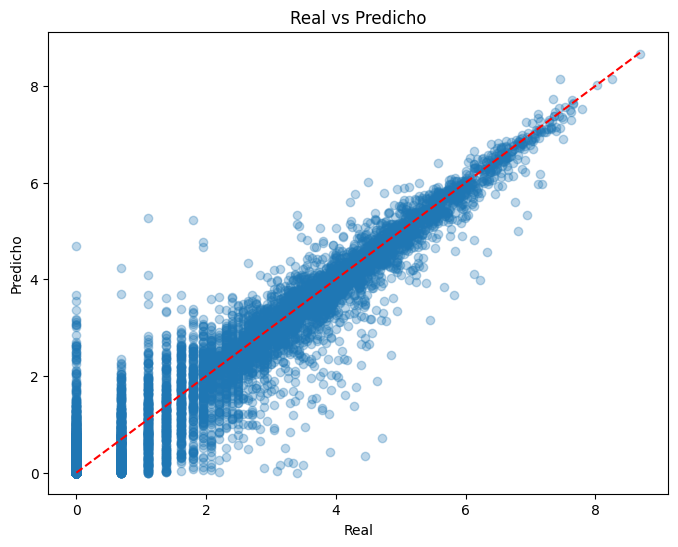

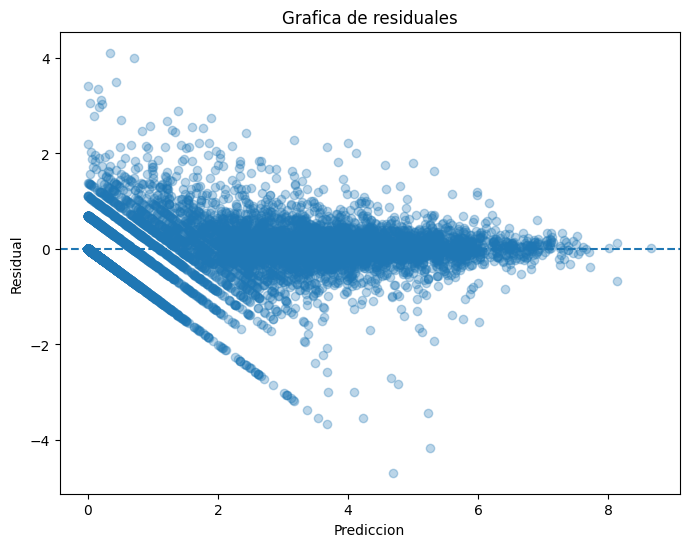

In [22]:
grafica_predicciones(y_test, y_pred)
grafica_residuales(y_test, y_pred)

# Comparación con línea base

Para verificar que el modelo aporta valor real, lo comparamos contra un **DummyRegressor** que simplemente predice la media del target en cada caso. Si el Random Forest no supera significativamente a este modelo trivial, significaría que las features elegidas no tienen poder predictivo.

In [23]:
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline

baseline = Pipeline(
    [("preprocessor", preprocessor), ("model", DummyRegressor(strategy="mean"))]
)

baseline.fit(X_train, y_train)

baseline_metricas, _ = evaluar_modelo(baseline, X_test, y_test)
display(baseline_metricas)

,Metrica,Valor
0,MAE,1.719015
1,MSE,3.904472
2,RMSE,1.975974
3,R2,-0.000034


El DummyRegressor obtiene un R² ≈ 0 (como es esperado, ya que predecir la media no explica variación). El Random Forest, con un R² significativamente mayor, demuestra que las features utilizadas capturan patrones reales de la incidencia delictiva.

# Persistencia

Guardamos el pipeline completo (preprocesador + modelo entrenado) usando `joblib`. Esto permite cargar el modelo en cualquier momento sin necesidad de reentrenarlo.

In [24]:
guardar_modelo(mejor_modelo, "../models/modelo_incidencia_delictiva.joblib")

Modelo guardado en ../models/modelo_incidencia_delictiva.joblib


# Prediccion

Ahora intentaremos predecir los valores en base al modelo. Queremos predecir la incidencia delictiva de los siguientes casos:

| entidad | bien_juridico_afectado | tipo_delito | subtipo_delito | modalidad | anio | mes | trimestre |
|---------|------------------------|-------------|----------------|-----------|------|-----|-----------|
| Ciudad de México | El patrimonio | Robo | Robo de vehiculo automotor | Robo de coche de 4 ruedas Con violencia | 2026 | 5 | 1 |
| Jalisco | La vida y la Integridad corporal | Homicidio | Homicidio doloso | Con arma de fuego | 2026 | 5 | 1 |

In [3]:
modelo = cargar_modelo("../models/modelo_incidencia_delictiva.joblib")

# Preparación de los datos de entrada
# Las features deben coincidir con las usadas en el entrenamiento:
# - Categóricas: entidad, bien_juridico_afectado, tipo_delito, subtipo_delito, modalidad
# - Numéricas: anio, mes, trimestre

datos_ejemplo = pd.DataFrame(
    {
        "entidad": ["Ciudad de México", "Jalisco"],
        "bien_juridico_afectado": ["El patrimonio", "La vida y la Integridad corporal"],
        "tipo_delito": ["Robo", "Homicidio"],
        "subtipo_delito": ["Robo de vehiculo automotor", "Homicidio doloso"],
        "modalidad": ["Robo de coche de 4 ruedas Con violencia", "Con arma de fuego"],
        "anio": [2026, 2026],
        "mes": [5, 5],
        "trimestre": [1, 1],
    }
)


# El modelo predice en escala logarítmica (log1p), por lo que debemos invertir la transformación
predicciones_log = modelo.predict(datos_ejemplo)
predicciones = np.expm1(predicciones_log)  # Inversión de log1p

resultados = datos_ejemplo.copy()
resultados["incidencia_predicha"] = predicciones.round(0).astype(int)

print("Predicciones de incidencia delictiva:")
resultados

Modelo cargado desde: ../models/modelo_incidencia_delictiva.joblib
Predicciones de incidencia delictiva:


,entidad,bien_juridico_afectado,tipo_delito,subtipo_delito,modalidad,anio,mes,trimestre,incidencia_predicha
0,Ciudad de México,El patrimonio,Robo,Robo de vehiculo automotor,Robo de coche de 4 ruedas Con violencia,2026,5,1,50
1,Jalisco,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,2026,5,1,61


# Conclusiones

El modelo de Random Forest logra predecir la incidencia delictiva estatal mensual con un R² de 0.93, superando ampliamente a la línea base (R² ≈ 0). Esto confirma que:

1. La incidencia delictiva en México está fuertemente determinada por la ubicación geográfica, el tipo de delito y el momento en el tiempo. El 93% de la variación en la incidencia delictiva se explica por la combinación de ubicación geográfica, clasificación delictiva y momento en el tiempo. Esto descarta la hipótesis de que la criminalidad sea un fenómeno aleatorio o caótico: sigue patrones estables y recurrentes que un modelo de aprendizaje automático puede capturar con alta precisión.

2. Las variables utilizadas (entidad, clasificación delictiva, año/mes/trimestre) son suficientes para construir un modelo predictivo robusto. Sobretodo con estos datos más recientes, ya que el EDA mostró que la incidencia delictiva no ha decrecido entre 2015 y 2025, con un incremento notable desde 2022. Además, se observa estacionalidad: los picos se concentran entre marzo y junio en los últimos años (antes eran mayo-agosto). El modelo captura estos ciclos a través de las features `anio`, `mes` y `trimestre`, lo que permite identificar cuándo ocurren los periodos de mayor riesgo.

3. Los patrones delictivos son **estables y predecibles** en condiciones normales, lo cual es relevante para la planeación de políticas de seguridad. En particular, la clasificación delictiva es el predictor más potente, ya que la jerarquía `bien_juridico → tipo → subtipo → modalidad` permite distinguir entre categorías con volúmenes drásticamente diferentes. Como se vio en el EDA, "Robo" es el delito más reportado, pero la modalidad (con violencia, sin violencia, de vehículo automotor, etc.) añade granularidad que el modelo aprovecha para hacer predicciones más precisas.

## Limitaciones

- El modelo aprende patrones históricos y no puede predecir anomalías como pandemias, crisis o cambios de política pública. El caso de 2020 (valores inusualmente bajos por COVID-19) es un ejemplo de evento que el modelo no anticiparía.
- Los datos dependen de denuncias ante el Ministerio Público, por lo que zonas con bajo reporte pueden tener valores artificialmente bajos.
- El modelo identifica correlaciones, no causalidades. Por ejemplo, saber que _"CDMX tiene alta incidencia de robo"_ no explica por qué ocurre, lo cual es algo ajeno a lo que se realiza en este proyecto.